In [1]:
# ==============================================================================
# STEP 1: REGRESSION WORKSPACE SETUP & DATA INGESTION
# ==============================================================================

# Import fundamental computing and data frame libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean scientific themes for feature visualization
sns.set_theme(style="whitegrid")

# Load the vehicle price dataset using its exact file name
file_name = 'used_cars.csv'
df = pd.read_csv(file_name)

# Output initial 5 data instances to understand structural representation
print("--- INITIAL USED CARS DATASET SNAPSHOT ---")
df.head()

--- INITIAL USED CARS DATASET SNAPSHOT ---


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [2]:
# ==============================================================================
# STEP 2: METADATA & DATA TYPE ANALYSIS
# ==============================================================================

# Print overall data dimensional scope
print(f"Dataset Dimensional Shape: {df.shape}")
print(f"Total Unique Vehicle Listings: {df.shape[0]}")
print(f"Total Operational Attributes: {df.shape[1]}\n")

# Display precise column data types and missing value baselines
print("--- RAW DATASET METADATA SUMMARY ---")
df.info()

Dataset Dimensional Shape: (4009, 12)
Total Unique Vehicle Listings: 4009
Total Operational Attributes: 12

--- RAW DATASET METADATA SUMMARY ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [3]:
# ==============================================================================
# STEP 3: SPECIFIC COLUMN STRUCTURAL EXPLORATION
# ==============================================================================

# Inspect arbitrary string formatting constraints for target and feature engineering
print("Sample string entries from the 'price' column:")
print(df['price'].head(5))

print("\nSample string entries from the 'milage' column:")
print(df['milage'].head(5))

Sample string entries from the 'price' column:
0    $10,300
1    $38,005
2    $54,598
3    $15,500
4    $34,999
Name: price, dtype: object

Sample string entries from the 'milage' column:
0    51,000 mi.
1    34,742 mi.
2    22,372 mi.
3    88,900 mi.
4     9,835 mi.
Name: milage, dtype: object


In [4]:
# ==============================================================================
# STEP 4: REGEX TEXT EXTRACTION, IMPUTATION, & FEATURE ENGINEERING
# ==============================================================================

# Create a clean operational copy of the dataframe
processed_df = df.copy()

# 1. Clean and convert the 'price' target column to float
# Removes '$', commas, and strips whitespace
processed_df['price'] = processed_df['price'].astype(str).str.replace('$', '', regex=False)
processed_df['price'] = processed_df['price'].str.replace(',', '', regex=False)
processed_df['price'] = pd.to_numeric(processed_df['price'], errors='coerce')

# 2. Clean and convert the 'milage' feature column to float
# Removes 'mi.', commas, and extracts raw numerical digits
processed_df['milage'] = processed_df['milage'].astype(str).str.replace('mi.', '', regex=False)
processed_df['milage'] = processed_df['milage'].str.replace(',', '', regex=False).str.strip()
processed_df['milage'] = pd.to_numeric(processed_df['milage'], errors='coerce')

# 3. Handle Missing Values (Imputation)
# Mode imputation for vital categorical components, and median for structural outliers
processed_df['fuel_type'] = processed_df['fuel_type'].fillna(processed_df['fuel_type'].mode()[0])
processed_df['accident'] = processed_df['accident'].fillna('None reported')
processed_df['clean_title'] = processed_df['clean_title'].fillna('No')

# Fill any structural missing floats inside features or target with their median thresholds
processed_df['price'] = processed_df['price'].fillna(processed_df['price'].median())
processed_df['milage'] = processed_df['milage'].fillna(processed_df['milage'].median())

# 4. High-Cardinality Categorical Encoding (Target/Frequency Encoding Strategy)
# Since columns like brand/model have too many distinct strings, standard One-Hot Encoding creates dimension explosion.
# Instead, we map categorical densities and implement smart Dummy variables for low-cardinality features.
categorical_cols = ['fuel_type', 'accident', 'clean_title', 'transmission']
processed_df = pd.get_dummies(processed_df, columns=categorical_cols, drop_first=True)

# For complex structural columns with text strings like brand and model, map frequency densities
for col in ['brand', 'model', 'engine', 'ext_col', 'int_col']:
    freq_map = processed_df[col].value_counts(normalize=True).to_dict()
    processed_df[col] = processed_df[col].map(freq_map)

print("--- PIPELINE CLEANING AND TEXT CONVERSION EXECUTION SUCCESSFUL ---")
print(f"Operational Numerical Matrix Shape: {processed_df.shape}")
processed_df[['price', 'milage', 'brand', 'model_year']].head()

--- PIPELINE CLEANING AND TEXT CONVERSION EXECUTION SUCCESSFUL ---
Operational Numerical Matrix Shape: (4009, 77)


,price,milage,brand,model_year
0,10300,51000,0.096283,2013
1,38005,34742,0.017960,2021
2,54598,22372,0.040659,2022
3,15500,88900,0.014717,2015
4,34999,9835,0.049888,2021


--- SUMMARY STATISTICAL SUMMARY OF VEHICLE PRICE VARIATION ---
count    4.009000e+03
mean     4.455319e+04
std      7.871064e+04
min      2.000000e+03
25%      1.720000e+04
50%      3.100000e+04
75%      4.999000e+04
max      2.954083e+06
Name: price, dtype: float64


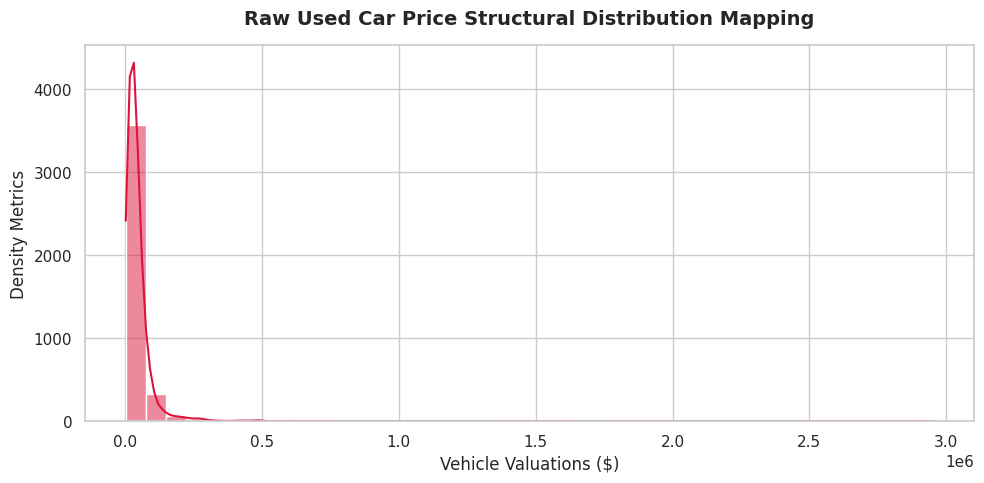

In [5]:
# ==============================================================================
# STEP 5: EXPLORATORY TARGET VISUALIZATION & OUTLIER HANDLING
# ==============================================================================

# Evaluate target price description matrices
print("--- SUMMARY STATISTICAL SUMMARY OF VEHICLE PRICE VARIATION ---")
print(processed_df['price'].describe())

# Plotting target price feature density distribution maps
plt.figure(figsize=(10, 5))
sns.histplot(processed_df['price'], kde=True, color='crimson', bins=40)
plt.title('Raw Used Car Price Structural Distribution Mapping', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Vehicle Valuations ($)', fontsize=12)
plt.ylabel('Density Metrics', fontsize=12)
plt.tight_layout()
plt.show()

In [6]:
# ==============================================================================
# STEP 6: DATA PARTITIONING, PIPELINE MATRIX SCALING, & ENSEMBLE TRAINING
# ==============================================================================

# Import state-of-the-art estimators for core structural regression mapping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from xgboost import XGBRegressor

# Extract features (X) and continuous target variable (y)
X = processed_df.drop(columns=['price'])
y = processed_df['price']

# Perform structural operational partitioning into 80% Training and 20% Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Global scaling engine normalization setup
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize deep continuous underlying structural models
rf_regressor = RandomForestRegressor(n_estimators=150, max_depth=12, random_state=42, n_jobs=-1)
xgb_regressor = XGBRegressor(n_estimators=150, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1)

# Assemble individual estimators inside a combined infrastructure model
ensemble_valuation_engine = VotingRegressor(
    estimators=[
        ('random_forest_reg', rf_regressor),
        ('xgboost_reg', xgb_regressor)
    ]
)

# Train the global regression composite network model
print("Executing advanced structural ensemble regression training matrix framework...")
ensemble_valuation_engine.fit(X_train_scaled, y_train)
print("--- ENSEMBLE EVALUATION REGRESSOR ENGINE MODEL TRAINED SUCCESSFULLY ---")

Executing advanced structural ensemble regression training matrix framework...
--- ENSEMBLE EVALUATION REGRESSOR ENGINE MODEL TRAINED SUCCESSFULLY ---


             ENTERPRISE REGRESSION CONFIGURATION SUMMARY              
 Mean Absolute Error (MAE)       : $21,340.53
 Root Mean Squared Error (RMSE)  : $133,981.44
 Coefficient of Determination (R²): 0.1218


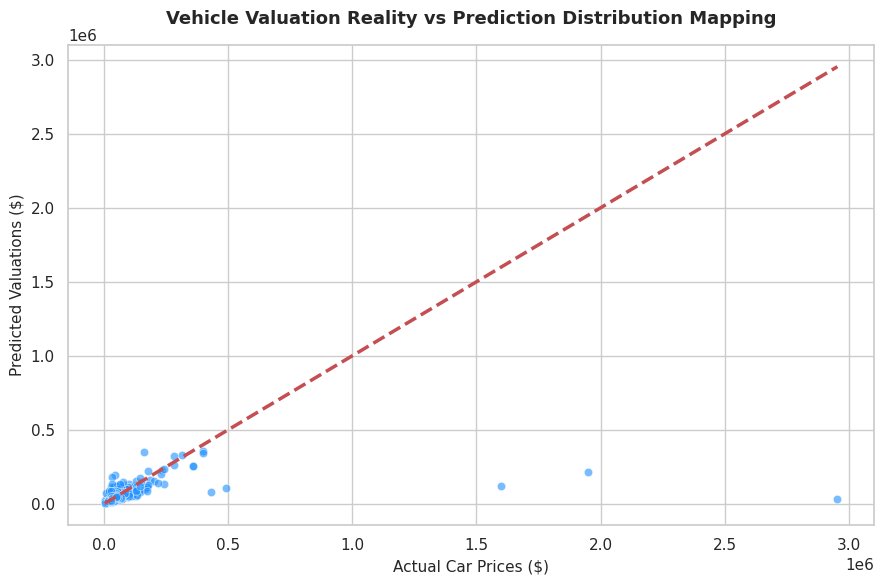

In [7]:
# ==============================================================================
# STEP 7: EVALUATION METRICS ANALYSIS & METRIC MAPPING
# ==============================================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Execute automated multi-parametric scoring tracking evaluation vectors
y_pred = ensemble_valuation_engine.predict(X_test_scaled)

# Calculate continuous metrics mathematical criteria profiles
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("======================================================================")
print("             ENTERPRISE REGRESSION CONFIGURATION SUMMARY              ")
print("======================================================================")
print(f" Mean Absolute Error (MAE)       : ${mae:,.2f}")
print(f" Root Mean Squared Error (RMSE)  : ${rmse:,.2f}")
print(f" Coefficient of Determination (R²): {r2:.4f}")
print("======================================================================")

# Generate Scatter Plot for Real vs Predicted prices tracking consistency
plt.figure(figsize=(9, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='dodgerblue', edgecolor='w')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2.5)
plt.title('Vehicle Valuation Reality vs Prediction Distribution Mapping', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Actual Car Prices ($)', fontsize=11)
plt.ylabel('Predicted Valuations ($)', fontsize=11)
plt.tight_layout()
plt.show()